In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
prices1 = pd.read_csv("prices_round_0_day_-1.csv", delimiter = ';')
prices2 = pd.read_csv("prices_round_0_day_-2.csv", delimiter = ';')

trades1 = pd.read_csv("trades_round_0_day_-1.csv", delimiter = ';')
trades2 = pd.read_csv("trades_round_0_day_-2.csv", delimiter = ';')

In [31]:
prices1.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


In [11]:
emeralds = prices1[prices1["product"] == "EMERALDS"]
tomatoes = prices1[prices1["product"] == "TOMATOES"]

In [35]:
emeralds.head(25)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
7,-1,300,EMERALDS,9992,11,9990,29,NaN,NaN,10008,11,10010,29,NaN,NaN,10000.0,0.0
9,-1,400,EMERALDS,9992,12,9990,25,NaN,NaN,10008,12,10010,25,NaN,NaN,10000.0,0.0
10,-1,500,EMERALDS,9992,12,9990,30,NaN,NaN,10008,12,10010,30,NaN,NaN,10000.0,0.0
12,-1,600,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
15,-1,700,EMERALDS,9992,12,9990,23,NaN,NaN,10008,12,10010,23,NaN,NaN,10000.0,0.0
17,-1,800,EMERALDS,9992,15,9990,29,NaN,NaN,10008,15,10010,29,NaN,NaN,10000.0,0.0
18,-1,900,EMERALDS,9992,15,9990,22,NaN,NaN,10008,15,10010,22,NaN,NaN,10000.0,0.0


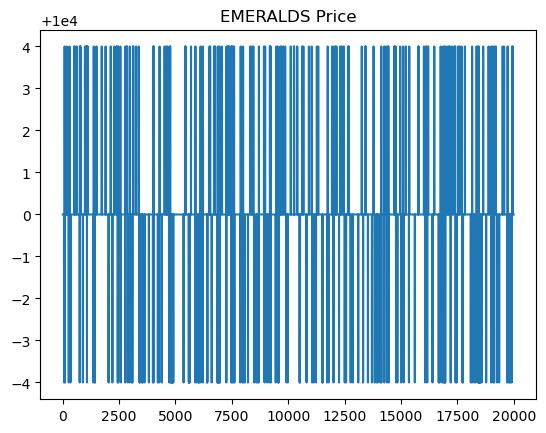

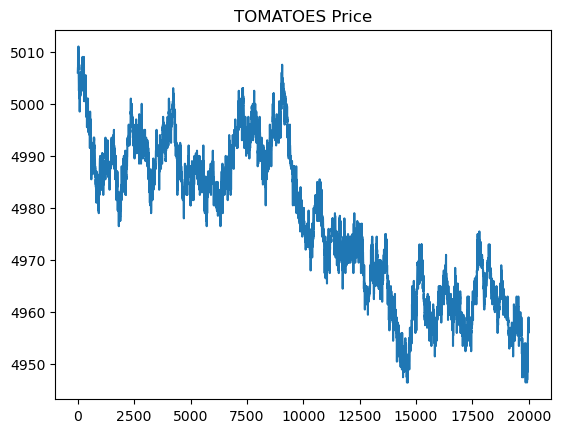

In [16]:
plt.plot(emeralds["mid_price"])
plt.title("EMERALDS Price")
plt.show()

plt.plot(tomatoes["mid_price"])
plt.title("TOMATOES Price")
plt.show()

In [17]:
df= pd.read_csv("") 

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
7,-1,300,EMERALDS,9992,11,9990,29,NaN,NaN,10008,11,10010,29,NaN,NaN,10000.0,0.0
9,-1,400,EMERALDS,9992,12,9990,25,NaN,NaN,10008,12,10010,25,NaN,NaN,10000.0,0.0


In [18]:
emeralds["mid_price"].describe()

count    10000.000000
mean      9999.998000
std          0.716692
min       9996.000000
25%      10000.000000
50%      10000.000000
75%      10000.000000
max      10004.000000
Name: mid_price, dtype: float64

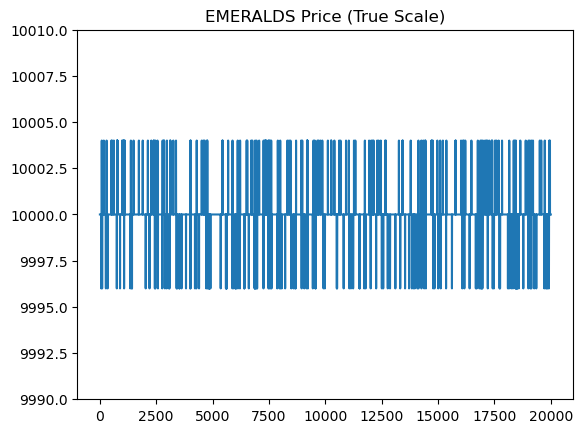

In [20]:
plt.plot(emeralds["mid_price"])
plt.ylim(9990, 10010)  # widen the scale
plt.title("EMERALDS Price (True Scale)")
plt.show()

In [22]:
tomatoes = prices1[prices1["product"] == "TOMATOES"].copy()

In [23]:
window = 20

tomatoes["rolling_mean"] = tomatoes["mid_price"].rolling(window).mean()
tomatoes["rolling_std"] = tomatoes["mid_price"].rolling(window).std()

In [24]:
tomatoes["z_score"] = (
    (tomatoes["mid_price"] - tomatoes["rolling_mean"]) 
    / tomatoes["rolling_std"]
)

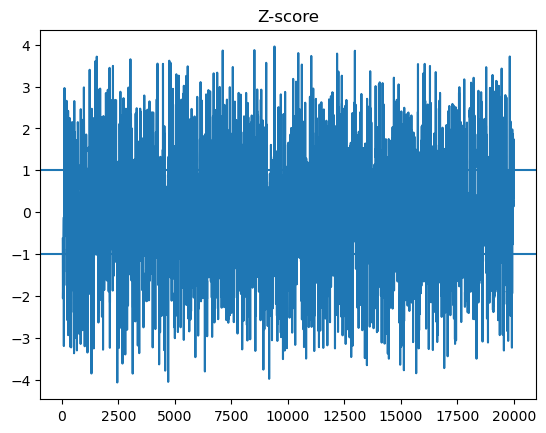

In [25]:
plt.plot(tomatoes["z_score"])
plt.axhline(1)
plt.axhline(-1)
plt.title("Z-score")
plt.show()

In [26]:
from collections import deque
import numpy as np

class Trader:

    def __init__(self):
        self.position = {"EMERALDS": 0, "TOMATOES": 0}
        self.history = {"TOMATOES": deque(maxlen=20)}

    def run(self, state):
        result = {}

        for product in state.order_depths:
            order_depth = state.order_depths[product]
            orders = []

            # Get best prices
            if len(order_depth.sell_orders) > 0:
                best_ask = min(order_depth.sell_orders)
            else:
                best_ask = None

            if len(order_depth.buy_orders) > 0:
                best_bid = max(order_depth.buy_orders)
            else:
                best_bid = None

            # ---------------- EMERALDS ----------------
            if product == "EMERALDS":
                fair_price = 10000
                pos = self.position["EMERALDS"]

                if best_ask and best_ask < fair_price and pos < 80:
                    orders.append(("BUY", best_ask, 5))

                if best_bid and best_bid > fair_price and pos > -80:
                    orders.append(("SELL", best_bid, 5))

            # ---------------- TOMATOES ----------------
            if product == "TOMATOES" and best_ask and best_bid:
                mid_price = (best_ask + best_bid) / 2
                self.history["TOMATOES"].append(mid_price)

                if len(self.history["TOMATOES"]) >= 20:
                    prices = list(self.history["TOMATOES"])
                    mean = np.mean(prices)
                    std = np.std(prices)

                    if std > 0:
                        z = (mid_price - mean) / std
                        pos = self.position["TOMATOES"]

                        if z < -1 and pos < 80:
                            orders.append(("BUY", best_ask, 5))

                        elif z > 1 and pos > -80:
                            orders.append(("SELL", best_bid, 5))

            result[product] = orders

        return result

In [36]:
# EMA (fast)
tomatoes["ema"] = tomatoes["mid_price"].ewm(span=10).mean()

# SMA (slow)
tomatoes["sma"] = tomatoes["mid_price"].rolling(window=50).mean()

In [37]:
window = 20

def compute_slope(series):
    x = np.arange(len(series))
    y = series.values
    slope = np.polyfit(x, y, 1)[0]
    return slope

tomatoes["slope"] = tomatoes["mid_price"].rolling(window).apply(compute_slope, raw=False)

In [38]:
tomatoes["std"] = tomatoes["mid_price"].rolling(window).std()

tomatoes["norm_slope"] = tomatoes["slope"] / tomatoes["std"]

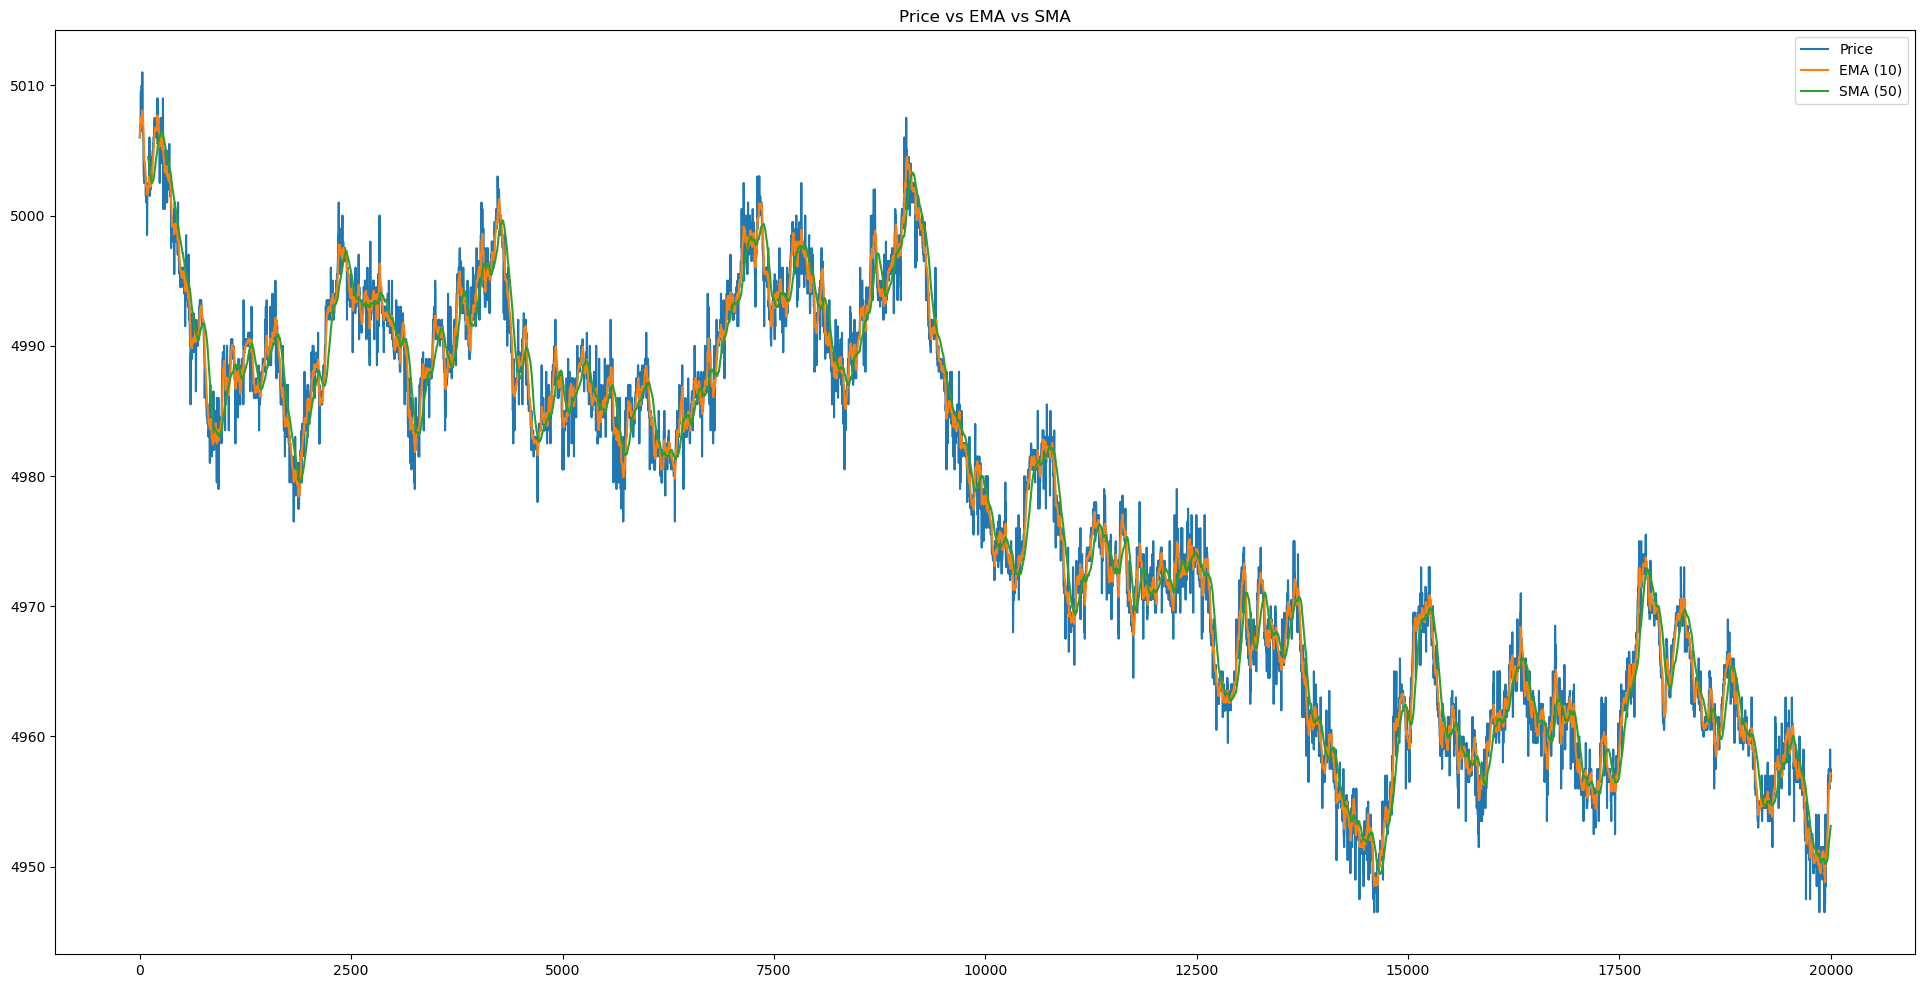

In [47]:
plt.figure(figsize=(24, 12))

plt.plot(tomatoes["mid_price"], label="Price")
plt.plot(tomatoes["ema"], label="EMA (10)")
plt.plot(tomatoes["sma"], label="SMA (50)")

plt.legend()
plt.title("Price vs EMA vs SMA")
plt.show()


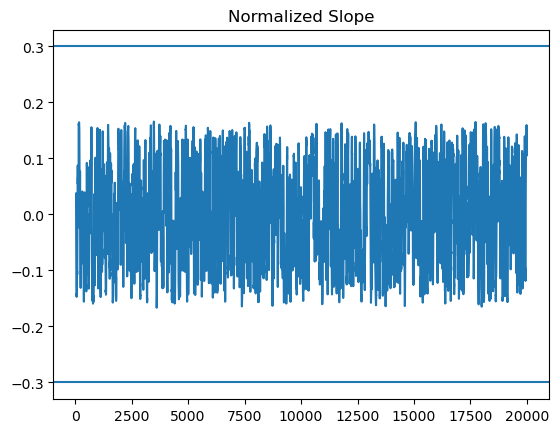

In [40]:
plt.figure()

plt.plot(tomatoes["norm_slope"])
plt.axhline(0.3)
plt.axhline(-0.3)

plt.title("Normalized Slope")
plt.show()

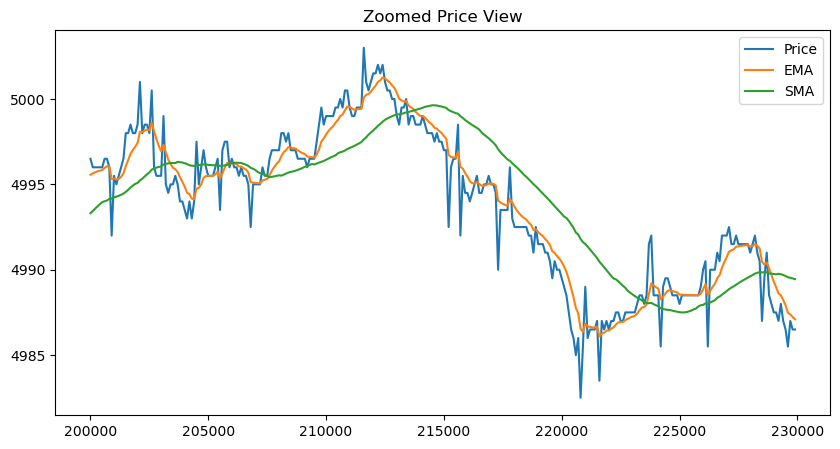

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(subset["timestamp"], subset["mid_price"], label="Price")
plt.plot(subset["timestamp"], subset["ema"], label="EMA")
plt.plot(subset["timestamp"], subset["sma"], label="SMA")

plt.legend()
plt.title("Zoomed Price View")
plt.show()

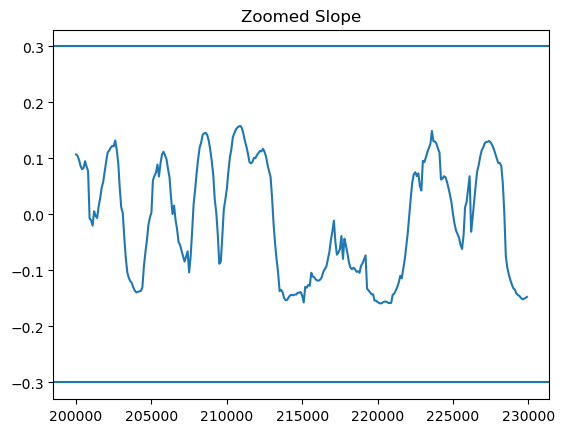

In [44]:
plt.figure()

plt.plot(subset["timestamp"], subset["norm_slope"])
plt.axhline(0.3)
plt.axhline(-0.3)

plt.title("Zoomed Slope")
plt.show()

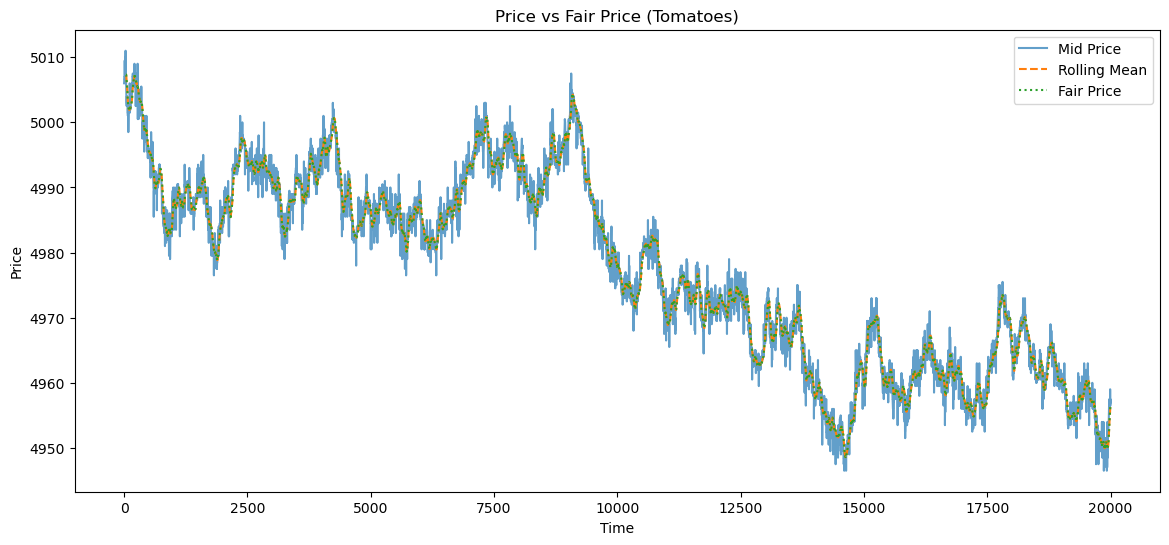

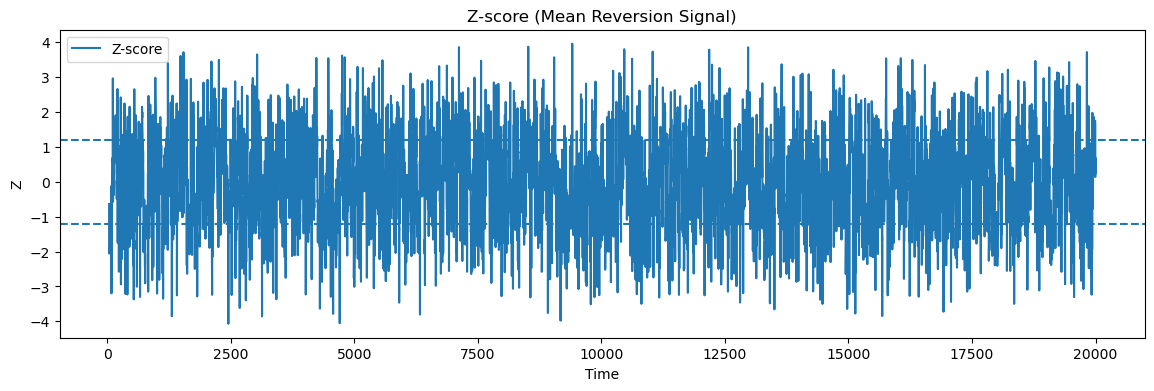

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("prices_round_0_day_-1.csv" , delimiter = ";") 

df = df[df["product"] == "TOMATOES"].copy()

df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2

window = 20

df["mean"] = df["mid_price"].rolling(window).mean()
df["std"] = df["mid_price"].rolling(window).std()

# Z SCORE 
df["z"] = (df["mid_price"] - df["mean"]) / df["std"]

pos = 0
df["fair_price"] = df["mean"] - 0.12 * pos


plt.figure(figsize=(14,6))
plt.plot(df["mid_price"], label="Mid Price", alpha=0.7)
plt.plot(df["mean"], label="Rolling Mean", linestyle="--")
plt.plot(df["fair_price"], label="Fair Price", linestyle=":")
plt.legend()
plt.title("Price vs Fair Price (Tomatoes)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


plt.figure(figsize=(14,4))
plt.plot(df["z"], label="Z-score")

# thresholds
plt.axhline(1.2, linestyle="--")
plt.axhline(-1.2, linestyle="--")

plt.title("Z-score (Mean Reversion Signal)")
plt.xlabel("Time")
plt.ylabel("Z")
plt.legend()
plt.show()

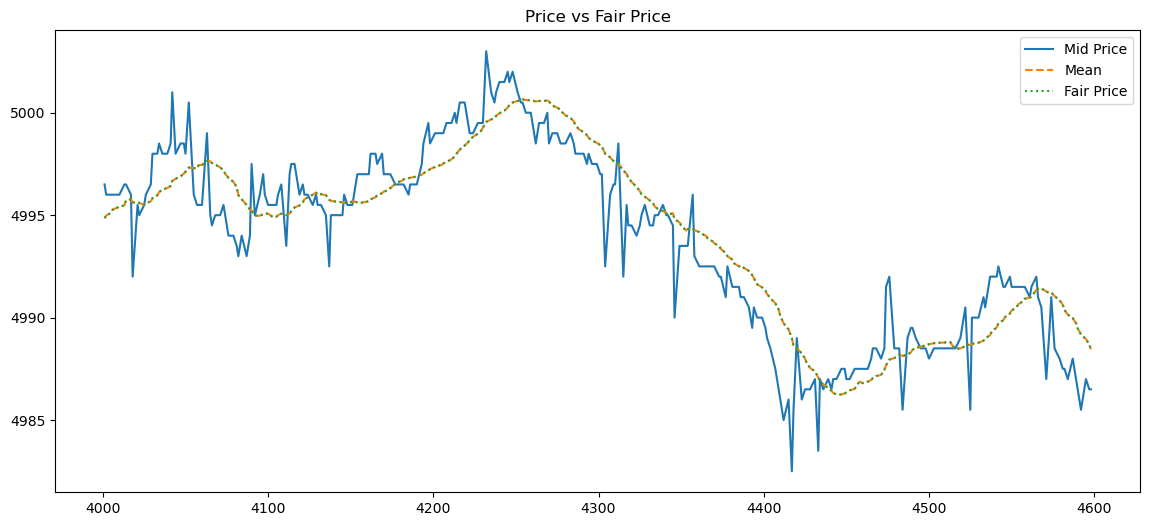

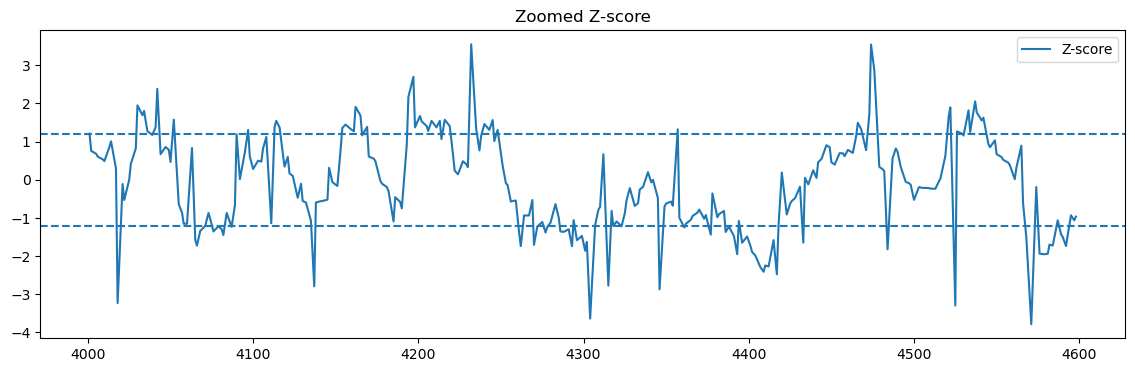

In [63]:

start = 2000
end = 2300

df_zoom = df.iloc[start:end]

plt.figure(figsize=(14,6))
plt.plot(df_zoom["mid_price"], label="Mid Price")
plt.plot(df_zoom["mean"], linestyle="--", label="Mean")
plt.plot(df_zoom["fair_price"], linestyle=":", label="Fair Price")

plt.title("Price vs Fair Price")
plt.legend()
plt.show()


plt.figure(figsize=(14,4))
plt.plot(df_zoom["z"], label="Z-score")

plt.axhline(1.2, linestyle="--")
plt.axhline(-1.2, linestyle="--")

plt.title("Zoomed Z-score")
plt.legend()
plt.show()